In [1]:
# Load the selected FNN features
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

RESULTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/results"
)

saved_features = np.load(
    RESULTS_DIR / "fnn_selected_feature_data.npz"
)

X_selected = saved_features["X_selected"]
y_users = saved_features["y_users"]

print("Selected FNN features loaded")
print("-" * 40)
print(f"Feature matrix shape: {X_selected.shape}")
print(f"Labels shape:         {y_users.shape}")
print(f"Number of users:      {len(np.unique(y_users))}")
print(f"Missing values:       {np.isnan(X_selected).sum()}")

print("\nUser sample counts:")
print(pd.Series(y_users).value_counts().sort_index())

Selected FNN features loaded
----------------------------------------
Feature matrix shape: (1081, 10)
Labels shape:         (1081,)
Number of users:      10
Missing values:       0

User sample counts:
112    101
13     117
2      136
23     132
24      90
49     101
52      95
55     117
70     108
78      84
Name: count, dtype: int64


In [2]:
# Define the verification CNN
def build_verification_fnn_model(input_features):
    """
    Build a binary one-vs-all FNN verification model.
    """

    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(input_features,)
        ),

        tf.keras.layers.Dense(
            5,
            activation="relu",
            name="hidden_layer_1"
        ),

        tf.keras.layers.Dense(
            5,
            activation="relu",
            name="hidden_layer_2"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            name="verification_output"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


verification_fnn_model = build_verification_fnn_model(
    input_features=X_selected.shape[1]
)

verification_fnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ verification_output (Dense)     │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Create balanced verification datasets
# Prepare balanced one-vs-all datasets for all users

random_generator = np.random.default_rng(42)

balanced_verification_data = {}

user_ids = np.sort(np.unique(y_users))

for target_user in user_ids:

    genuine_indices = np.where(
        y_users == target_user
    )[0]

    impostor_indices = np.where(
        y_users != target_user
    )[0]

    # Match the impostor count to the genuine count
    selected_impostor_indices = random_generator.choice(
        impostor_indices,
        size=len(genuine_indices),
        replace=False
    )

    selected_indices = np.concatenate([
        genuine_indices,
        selected_impostor_indices
    ])

    # Genuine = 1, impostor = 0
    binary_labels = np.concatenate([
        np.ones(len(genuine_indices), dtype=np.int32),
        np.zeros(len(selected_impostor_indices), dtype=np.int32)
    ])

    # Shuffle genuine and impostor samples together
    shuffle_order = random_generator.permutation(
        len(selected_indices)
    )

    selected_indices = selected_indices[shuffle_order]
    binary_labels = binary_labels[shuffle_order]

    balanced_verification_data[target_user] = {
        "X": X_selected[selected_indices],
        "y": binary_labels
    }


# Verify the balancing
balance_summary = []

for target_user, data in balanced_verification_data.items():

    labels = data["y"]

    balance_summary.append({
        "Target user": target_user,
        "Total samples": len(labels),
        "Genuine samples": int(np.sum(labels == 1)),
        "Impostor samples": int(np.sum(labels == 0)),
        "Feature shape": data["X"].shape
    })

balance_summary_df = pd.DataFrame(balance_summary)

display(balance_summary_df)

,Target user,Total samples,Genuine samples,Impostor samples,Feature shape
0,112,202,101,101,"(202, 10)"
1,13,234,117,117,"(234, 10)"
2,2,272,136,136,"(272, 10)"
3,23,264,132,132,"(264, 10)"
4,24,180,90,90,"(180, 10)"
5,49,202,101,101,"(202, 10)"
6,52,190,95,95,"(190, 10)"
7,55,234,117,117,"(234, 10)"
8,70,216,108,108,"(216, 10)"
9,78,168,84,84,"(168, 10)"


In [4]:
# Train all 10 FNN verification models
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

VERIFICATION_EPOCHS = 40
VERIFICATION_BATCH_SIZE = 32
VERIFICATION_SPLITS = 5

verification_results = []
verification_roc_curves = {}

for user_number, target_user in enumerate(user_ids):

    print(
        f"Training verification models for user "
        f"{target_user} ({user_number + 1}/{len(user_ids)})..."
    )

    X_user = balanced_verification_data[target_user]["X"]
    y_user = balanced_verification_data[target_user]["y"]

    user_cross_validator = StratifiedKFold(
        n_splits=VERIFICATION_SPLITS,
        shuffle=True,
        random_state=42
    )

    all_user_true_labels = []
    all_user_scores = []

    for fold_number, (train_indices, validation_indices) in enumerate(
        user_cross_validator.split(X_user, y_user),
        start=1
    ):

        X_train_raw = X_user[train_indices]
        X_validation_raw = X_user[validation_indices]

        y_train = y_user[train_indices]
        y_validation = y_user[validation_indices]

        # Fit scaling only on the training fold
        fold_scaler = StandardScaler()

        X_train_scaled = fold_scaler.fit_transform(
            X_train_raw
        )

        X_validation_scaled = fold_scaler.transform(
            X_validation_raw
        )

        # Build a new binary FNN for this fold
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(
            42 + user_number + fold_number
        )

        fold_model = build_verification_fnn_model(
            input_features=X_train_scaled.shape[1]
        )

        fold_model.fit(
            X_train_scaled,
            y_train,
            epochs=VERIFICATION_EPOCHS,
            batch_size=VERIFICATION_BATCH_SIZE,
            verbose=0
        )

        # Store probability scores for ROC-based evaluation
        validation_scores = (
            fold_model(
                X_validation_scaled,
                training=False
            )
            .numpy()
            .ravel()
        )

        all_user_true_labels.extend(y_validation)
        all_user_scores.extend(validation_scores)

    # Convert out-of-fold results to arrays
    all_user_true_labels = np.array(
        all_user_true_labels
    )

    all_user_scores = np.array(
        all_user_scores
    )

    # ROC curve and AUC
    false_positive_rate, true_positive_rate, thresholds = (
        roc_curve(
            all_user_true_labels,
            all_user_scores
        )
    )

    user_auc = roc_auc_score(
        all_user_true_labels,
        all_user_scores
    )

    # Ignore the first infinite ROC threshold
    finite_threshold_indices = np.isfinite(thresholds)

    finite_fpr = false_positive_rate[
        finite_threshold_indices
    ]

    finite_tpr = true_positive_rate[
        finite_threshold_indices
    ]

    finite_thresholds = thresholds[
        finite_threshold_indices
    ]

    false_rejection_rates = 1 - finite_tpr

    eer_index = np.argmin(
        np.abs(finite_fpr - false_rejection_rates)
    )

    eer_threshold = finite_thresholds[eer_index]

    far = finite_fpr[eer_index]
    frr = false_rejection_rates[eer_index]
    eer = (far + frr) / 2

    verification_results.append({
        "Target user": target_user,
        "FAR": far,
        "FRR": frr,
        "EER": eer,
        "AUC": user_auc,
        "EER threshold": eer_threshold
    })

    verification_roc_curves[target_user] = {
        "FPR": false_positive_rate,
        "TPR": true_positive_rate,
        "AUC": user_auc
    }

    print(
        f"  FAR: {far:.4f} | "
        f"FRR: {frr:.4f} | "
        f"EER: {eer:.4f} | "
        f"AUC: {user_auc:.4f}"
    )


verification_results_df = pd.DataFrame(
    verification_results
)

print("\nVerification results for all users:")
display(verification_results_df)

print("\nAverage verification results:")
display(
    verification_results_df[
        ["FAR", "FRR", "EER", "AUC"]
    ].agg(["mean", "std"])
)

Training verification models for user 112 (1/10)...
  FAR: 0.1683 | FRR: 0.2079 | EER: 0.1881 | AUC: 0.9034
Training verification models for user 13 (2/10)...
  FAR: 0.1709 | FRR: 0.2051 | EER: 0.1880 | AUC: 0.9311
Training verification models for user 2 (3/10)...
  FAR: 0.0956 | FRR: 0.0956 | EER: 0.0956 | AUC: 0.9538
Training verification models for user 23 (4/10)...
  FAR: 0.0909 | FRR: 0.0909 | EER: 0.0909 | AUC: 0.9602
Training verification models for user 24 (5/10)...
  FAR: 0.2222 | FRR: 0.2556 | EER: 0.2389 | AUC: 0.8828
Training verification models for user 49 (6/10)...
  FAR: 0.1485 | FRR: 0.1386 | EER: 0.1436 | AUC: 0.8958
Training verification models for user 52 (7/10)...
  FAR: 0.2000 | FRR: 0.2000 | EER: 0.2000 | AUC: 0.9401
Training verification models for user 55 (8/10)...
  FAR: 0.0342 | FRR: 0.0427 | EER: 0.0385 | AUC: 0.9963
Training verification models for user 70 (9/10)...
  FAR: 0.1389 | FRR: 0.1296 | EER: 0.1343 | AUC: 0.9288
Training verification models for user

,Target user,FAR,FRR,EER,AUC,EER threshold
0,112,0.168317,0.207921,0.188119,0.903441,0.556619
1,13,0.170940,0.205128,0.188034,0.931113,0.537040
2,2,0.095588,0.095588,0.095588,0.953774,0.548751
3,23,0.090909,0.090909,0.090909,0.960170,0.546427
4,24,0.222222,0.255556,0.238889,0.882840,0.543822
5,49,0.148515,0.138614,0.143564,0.895795,0.556416
6,52,0.200000,0.200000,0.200000,0.940111,0.614118
7,55,0.034188,0.042735,0.038462,0.996347,0.537114
8,70,0.138889,0.129630,0.134259,0.928755,0.525304
9,78,0.071429,0.059524,0.065476,0.969388,0.543233



Average verification results:


,FAR,FRR,EER,AUC
mean,0.134100,0.142560,0.138330,0.936173
std,0.059746,0.071625,0.065205,0.035359


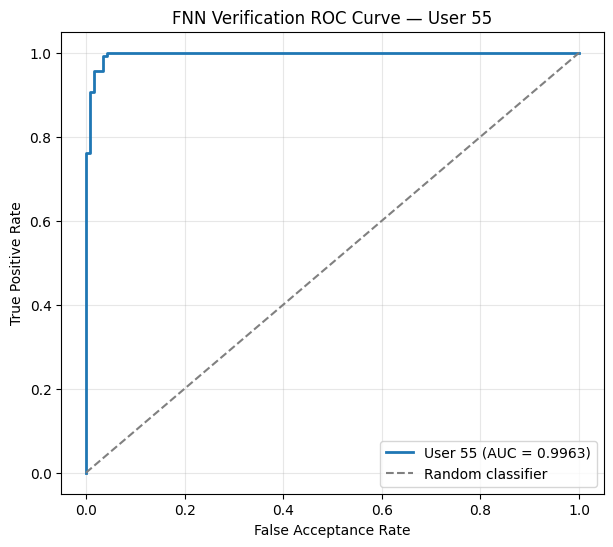

Saved FNN verification results to:
/content/drive/MyDrive/processed_data/results


In [6]:
# Plot one ROC curve and save FNN results
from pathlib import Path
import matplotlib.pyplot as plt

PLOTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/plots"
)

RESULTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/results"
)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# Choose one user for the required ROC plot
roc_user = "55"
roc_data = verification_roc_curves[roc_user]

plt.figure(figsize=(7, 6))

plt.plot(
    roc_data["FPR"],
    roc_data["TPR"],
    linewidth=2,
    label=f"User {roc_user} "
          f"(AUC = {roc_data['AUC']:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.xlabel("False Acceptance Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"FNN Verification ROC Curve — User {roc_user}"
)
plt.legend()
plt.grid(True, alpha=0.3)

roc_path = (
    PLOTS_DIR / "fnn_verification_roc_user_55.png"
)

plt.savefig(
    roc_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Save verification metrics
verification_results_df.to_csv(
    RESULTS_DIR / "fnn_verification_results_by_user.csv",
    index=False
)

verification_results_df[
    ["FAR", "FRR", "EER", "AUC"]
].agg(["mean", "std"]).to_csv(
    RESULTS_DIR / "fnn_verification_summary.csv"
)

print("Saved FNN verification results to:")
print(RESULTS_DIR)